# Data Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

/home/lucazini03/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submission = pd.read_csv("sample_submission.csv")

In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", submission.shape)

Train shape: (750000, 18)
Test shape: (250000, 17)
Submission shape: (250000, 2)


The shape of the train, test, and submission datasets is as follows:
- Train shape: (750k, 18)
- Test shape: (250k, 17): the test set has one less column than the train set, which is expected since it does not include the target variable. That is the way competitions are usually structured, to prevent data leakage and ensure that the model is evaluated on unseen data.
- Submission shape: (250k, 2): those two columns are usually the ID column and the target variable column, where I will fill in your predictions for the test set.

In [5]:
train.head(10)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
5,5,24,admin.,single,secondary,no,1882,yes,no,cellular,20,apr,1010,3,-1,0,unknown,0
6,6,39,blue-collar,married,secondary,no,0,no,no,telephone,21,nov,90,1,-1,0,unknown,0
7,7,50,admin.,single,secondary,no,1595,no,no,telephone,31,jul,49,25,-1,0,unknown,0
8,8,46,blue-collar,married,primary,no,1463,no,no,cellular,4,aug,50,1,-1,0,unknown,0
9,9,39,management,divorced,tertiary,no,25,yes,no,cellular,8,may,119,1,-1,0,unknown,0


We now check if there are any missing values in the train and test datasets, as this can affect the performance of our model.

In [6]:
# missing values
if train.isnull().sum().sum() == 0 and test.isnull().sum().sum() == 0:
    print("No missing values in train and test datasets.")

No missing values in train and test datasets.


In [7]:
# we now graphically check what values each variable can assume
for column in train.columns:
    print(f"Unique values in {column}: {train[column].unique()}")
    print('-------------------------------------')


Unique values in id: [     0      1      2 ... 749997 749998 749999]
-------------------------------------
Unique values in age: [42 38 36 27 26 24 39 50 46 32 37 57 33 47 35 49 77 40 54 56 51 30 67 58
 59 45 43 29 48 31 28 34 60 52 41 81 23 62 53 72 55 25 44 61 63 69 75 71
 64 22 83 70 80 21 65 74 68 19 73 66 79 20 84 86 76 18 82 78 87 85 88 94
 93 89 92 95 90 91]
-------------------------------------
Unique values in job: ['technician' 'blue-collar' 'student' 'admin.' 'management' 'entrepreneur'
 'self-employed' 'unknown' 'services' 'retired' 'housemaid' 'unemployed']
-------------------------------------
Unique values in marital: ['married' 'single' 'divorced']
-------------------------------------
Unique values in education: ['secondary' 'primary' 'tertiary' 'unknown']
-------------------------------------
Unique values in default: ['no' 'yes']
-------------------------------------
Unique values in balance: [    7   514   602 ... 13023  4003  8218]
---------------------------------

### Bank client data
- Age (numeric)
- Job (categorical): job descriptions
- Marital (categorical): marital status
- Education (categorical): education level
- Default (categorical): has credit card?
- Balance (numeric): average yearly balance in euros
- Housing (categorical): has housing loan?
- Loan (categorical): has personal loan?

### Related with the last contact of the current campaign
A campaign is a planned marketing effort over a period of time, aimed at a group of clients.
Here, it’s a phone-based campaign: the bank calls clients to ask if they want to subscribe to a term deposit. A contact is one attempt to reach a client during a campaign. The last contact is the most recent attempt to reach the client during the current campaign, and its attributes can provide insights into the client's behavior and preferences.

- Contact (categorical): contact communication type
- Day (numeric): last contact day of the month
- Month (categorical): last contact month of the year
- Duration (numeric): last contact duration, in seconds

### Other attributes
P stands for previous, and it refers to the previous campaign. The attributes related to the previous campaign can provide insights into the client's past interactions with the bank and their likelihood of subscribing to a term deposit.

- Campaign (numeric): number of contacts performed during this campaign and for this client (includes last contact)
- Pdays (numeric): number of days that passed by after the client was last contacted from a previous campaign. If the value is -1, it means the client was not previously contacted.
- Previous (numeric): number of contacts performed before this campaign and for this client
- Poutcome (categorical): outcome of the previous marketing campaign

### Target variable
- Y (categorical): has the client subscribed a term deposit? (binary: "yes or "no")

# Data preprocessing

In [8]:
# id is not a useful feature for our model, so we drop it from both datasets

train.drop("id", axis=1, inplace=True)
test.drop("id", axis=1, inplace=True)

### Categorical variables

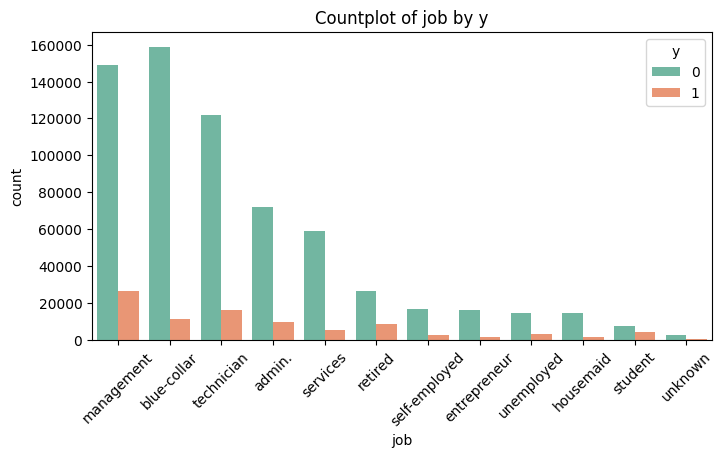

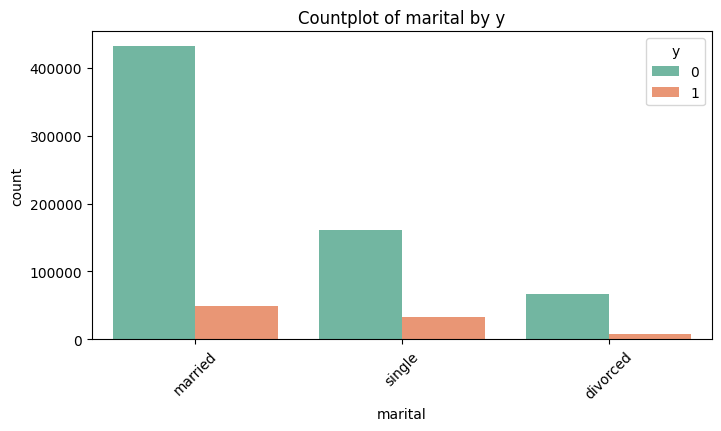

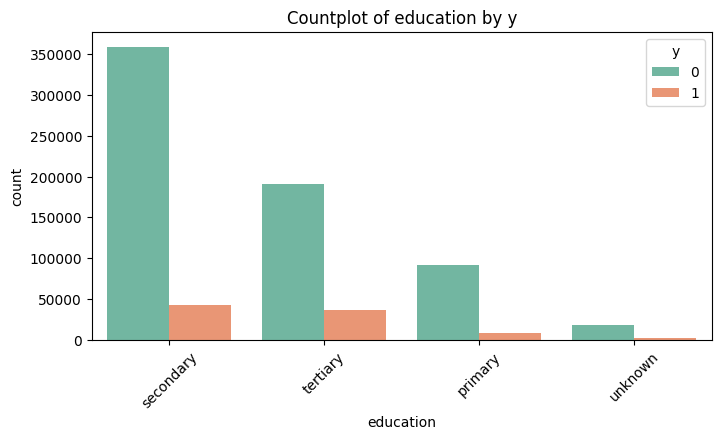

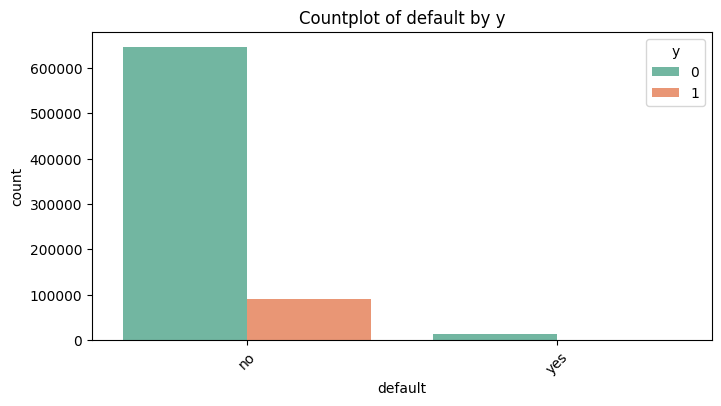

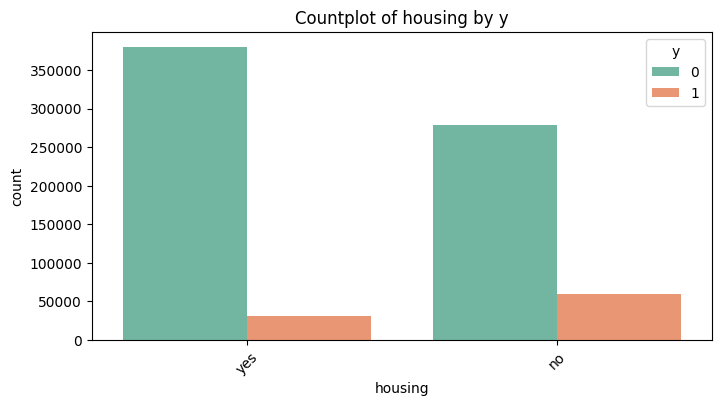

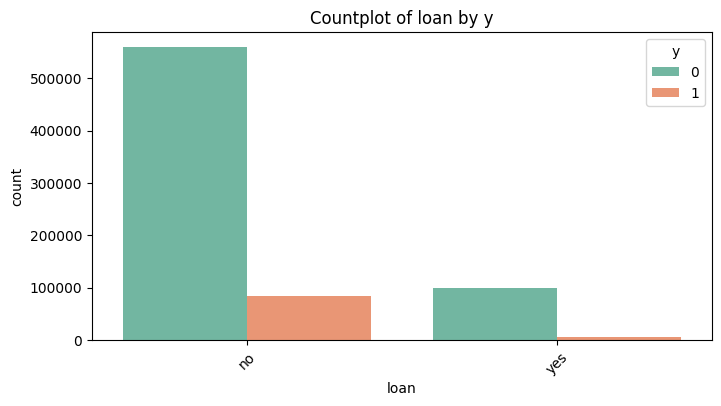

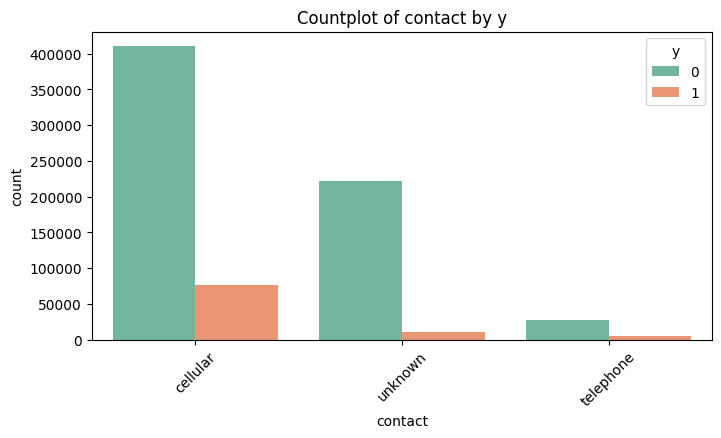

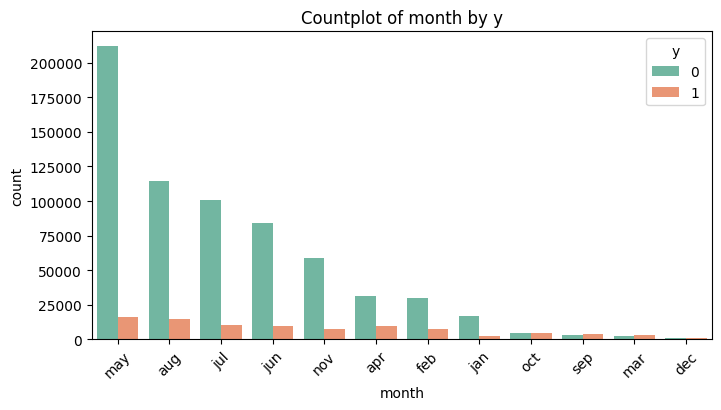

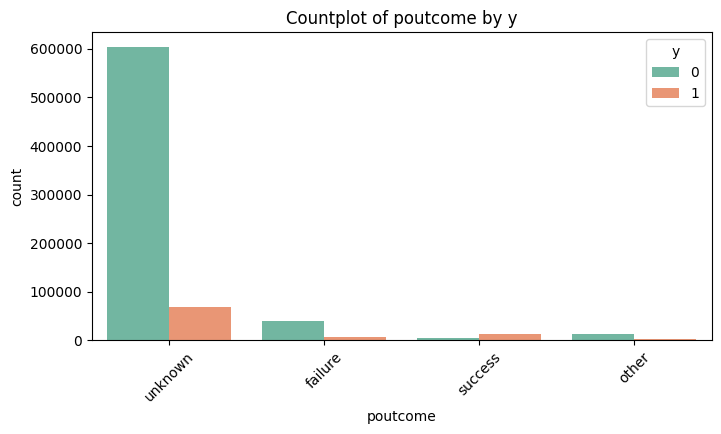

Target variable distribution:
y
0    87.934933
1    12.065067
Name: proportion, dtype: float64


In [9]:
# categorical features
categorical_cols = train.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=train,
        x=col,
        order=train[col].value_counts().index,
        hue="y",              # different colors for target classes
        palette="Set2"        # choose any seaborn palette
    )
    plt.title(f'Countplot of {col} by y')
    plt.xticks(rotation=45)
    plt.legend(title="y")
    plt.show()

print("Target variable distribution:")
print(train['y'].value_counts(normalize=True) * 100)

In [10]:
# print, for every categorical variable, and for every value that the variable can assume, the percentage of samples in the train dataset that have that value and belong to class 1 (y=1)
for col in categorical_cols:
    print(f"Percentage of samples with y=1 for each value of {col}:")
    percentages = train.groupby(col)['y'].mean() * 100
    print(percentages)
    print('-------------------------------------')

Percentage of samples with y=1 for each value of job:
job
admin.           11.645315
blue-collar       6.743774
entrepreneur      8.138616
housemaid         8.465309
management       15.039222
retired          24.624130
self-employed    12.944269
services          8.271426
student          34.078355
technician       11.832130
unemployed       17.982307
unknown          12.067192
Name: y, dtype: float64
-------------------------------------
Percentage of samples with y=1 for each value of marital:
marital
divorced    11.157552
married     10.187225
single      17.045280
Name: y, dtype: float64
-------------------------------------
Percentage of samples with y=1 for each value of education:
education
primary       8.309718
secondary    10.549115
tertiary     16.264923
unknown      13.338654
Name: y, dtype: float64
-------------------------------------
Percentage of samples with y=1 for each value of default:
default
no     12.194652
yes     4.630711
Name: y, dtype: float64
--------------

In [11]:
# Encoding categorical variables: let the user choose the method

def encode_categorical(train, test, method='onehot'):
    if method == 'label':
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(pd.concat([train[col], test[col]], axis=0))
            train[col] = le.transform(train[col])
            test[col] = le.transform(test[col])
    elif method == 'onehot':
        combined = pd.concat([train, test], axis=0)
        combined_encoded = pd.get_dummies(combined, columns=categorical_cols, drop_first=False)
        train_encoded = combined_encoded.iloc[:len(train), :].copy()
        test_encoded = combined_encoded.iloc[len(train):, :].copy()
        return train_encoded, test_encoded
    else:
        raise ValueError("Invalid encoding method. Choose 'label', or 'onehot'.")
    return train, test

### Numerical variables

In [12]:
#we describe the train dataset to get a statistical summary of the numerical features (not the categorical ones!)
numeric_cols = train.select_dtypes(include=[np.number]).columns
train[numeric_cols].describe()

,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [13]:
numerical_features = [col for col in numeric_cols if col != 'y']
print(numerical_features)

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [14]:
# for col in numerical_features:
#     fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#     # Histogram
#     sns.histplot(train[col], kde=True, bins=25, ax=axes[0])
#     axes[0].set_title(f'Distribution of {col}')

#     # Boxplot
#     sns.boxplot(x=train[col], ax=axes[1])
#     axes[1].set_title(f'Boxplot of {col}')

#     plt.tight_layout()
#     plt.show()


In [15]:
# let's double check skewness of numerical features, that we can also empirically see from the histograms and boxplots
skewness = train[numerical_features].skew() # positive skewness means right-skewed, negative skewness means left-skewed
print("Skewness of numerical features:")
print(skewness.sort_values(ascending=False))

Skewness of numerical features:
previous    13.749885
balance     12.304123
campaign     4.810437
pdays        3.625049
duration     2.048776
age          0.586137
day          0.054014
dtype: float64


Some of the numerical features are highly skewed, such as:
- previous: it makes sense, since most clients were not contacted in previous campaigns, so the distribution is skewed towards zero.
- balance: it is kewed because some clients may have very high balances, while most have little money. 
- campaign: it is skewed because most clients may have been contacted only once (which is the minimum value since it also includes last contact), while a few clients may have been contacted many times.
- pdays: it is skewed because most clients were not contacted in previous campaigns (pdays = -1), while a few clients may have been contacted recently (pdays close to zero) or a long time ago (pdays with high positive values).
- duration: it is skewed because most calls may have been short, while a few calls may have been very long.

Since balance can have negative values, we cannot apply a log transformation to it, but we can apply a cube-root transformation, which can handle negative values and also reduce skewness.

Some ideas of feataure engineering to help the models:
- for pdays, we can create a new binary feature indicating whether the client was previously contacted or not (pdays = -1), and also create a new feature with the log-transformed pdays for those clients that were previously contacted (pdays > -1).


In [16]:
# for pdays, we can create a new binary feature indicating whether the client was previously contacted or not (pdays = -1), and also create a new feature with the log-transformed pdays for those clients that were previously contacted (pdays > -1).

train_transformed = train.copy()
test_transformed = test.copy()

#pdays
train_transformed['previously_contacted'] = (train['pdays'] != -1).astype(int)
test_transformed['previously_contacted'] = (test['pdays'] != -1).astype(int)

In [17]:
# # Clip values at the 99th percentile
# upper_limit = train_transformed['previous'].quantile(0.97)
# train_transformed['previous_clipped'] = train['previous'].clip(upper=upper_limit)
# test_transformed['previous_clipped'] = test['previous'].clip(upper=upper_limit)
# numerical_features = numerical_features + ['previous_clipped']
# skewness = train_transformed['previous_clipped'].skew()
# print(f"Skewness of previous_clipped: {skewness}")

In [18]:
skewness = train_transformed[numerical_features].skew() # positive skewness means right-skewed, negative skewness means left-skewed
print(skewness)

age          0.586137
balance     12.304123
day          0.054014
duration     2.048776
campaign     4.810437
pdays        3.625049
previous    13.749885
dtype: float64


In [19]:
def transform_and_plot_skewed(train_df, test_df, cols, plot=True):
    for col in cols:
        #cube-root transformation for balance, since it can have negative values
        if col == 'balance':  # we apply cube-root transformation only to balance, since it is the most skewed feature and it can have negative values
            train_df[col] = np.cbrt(train_df[col])
            test_df[col] = np.cbrt(test_df[col])
        elif col == 'pdays':
            train_df[col] = np.where(train_df[col] > -1, np.log1p(train_df[col]), 0) # we use np.log1p to handle the case when pdays = 0, since log(0) is undefined. For pdays = -1, we set the log-transformed value to 0 (or any constant), since it indicates that the client was not previously contacted.
            test_df[col] = np.where(test_df[col] > -1, np.log1p(test_df[col]), 0) # we use np.log1p to handle the case when
        else:
            train_df[col] = np.log1p(train_df[col]) # log1p is used to handle the case when the feature can have zero values, since log(0) is undefined
            test_df[col] = np.log1p(test_df[col]) # log1p is used to handle the case when the feature can have zero values, since log(0) is undefined

        if plot:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            sns.histplot(train_df[col], kde=True, bins=25, ax=axes[0])
            axes[0].set_title(f'Distribution of transformed {col}')
            sns.boxplot(x=train_df[col], ax=axes[1])
            axes[1].set_title(f'Boxplot of transformed {col}')
            plt.tight_layout()
            plt.show()

skewed_features = skewness[skewness.abs() > 1].index.tolist()

transform_and_plot_skewed(train_transformed, test_transformed, skewed_features, plot=False)

/usr/lib/python3/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [20]:
skewness_transformed = train_transformed[numerical_features].skew() # positive skewness means right-skewed, negative skewness means left-skewed
print("Skewness of numerical features (after transformation):")
print(skewness_transformed.sort_values(ascending=False))

Skewness of numerical features (after transformation):
previous    3.619914
pdays       2.664730
campaign    1.323181
age         0.586137
day         0.054014
balance    -0.317423
duration   -0.356506
dtype: float64


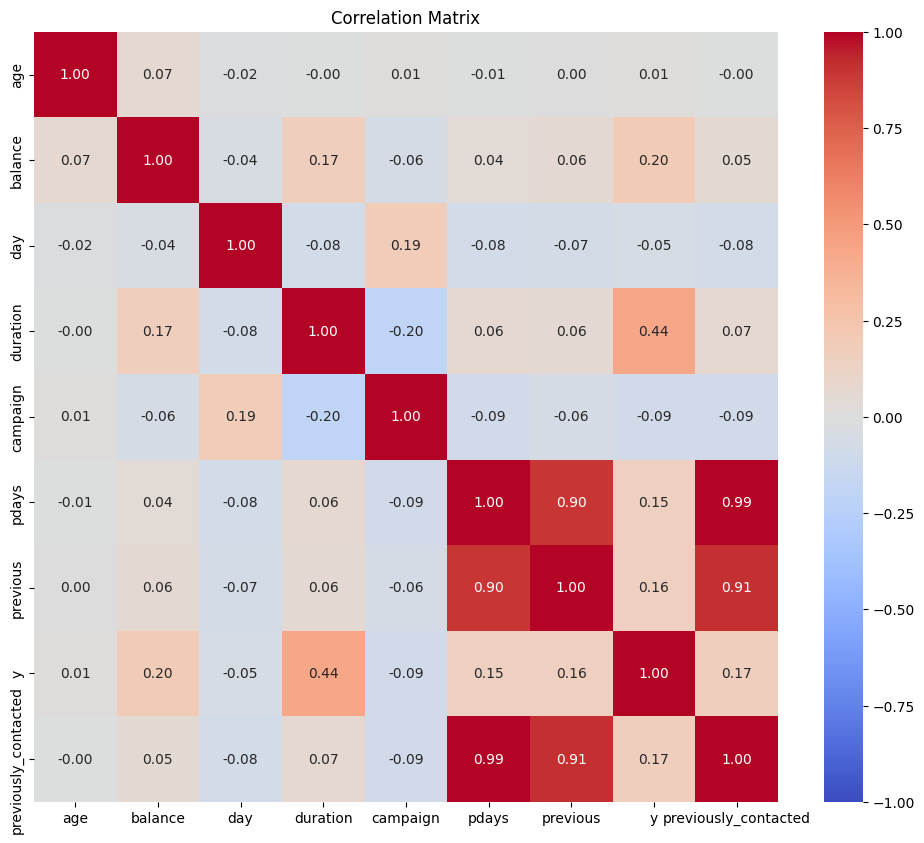

In [21]:
# correlation matrix

numeric_cols = train_transformed.select_dtypes(include=[np.number]).columns
numerical_features = [col for col in numeric_cols if col != 'y']

plt.figure(figsize=(12, 10))
sns.heatmap(train_transformed[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# ML MODELS

In [22]:
train_transformed.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,previously_contacted
0,42,technician,married,secondary,no,1.912931,no,no,cellular,25,aug,4.770685,1.386294,0.0,0.0,unknown,0,0
1,38,blue-collar,married,secondary,no,8.010403,no,no,unknown,18,jun,5.225747,0.693147,0.0,0.0,unknown,0,0
2,36,blue-collar,married,secondary,no,8.443688,yes,no,unknown,14,may,4.718499,1.098612,0.0,0.0,unknown,0,0
3,27,student,single,secondary,no,3.239612,yes,no,unknown,28,may,2.397895,1.098612,0.0,0.0,unknown,0,0
4,26,technician,married,secondary,no,9.615398,yes,no,cellular,3,feb,6.805723,0.693147,0.0,0.0,unknown,1,0


In [23]:
# train_transformed only contains the numerical features, so we need to encode the categorical features in the original train and test datasets, and then concatenate the encoded categorical features with the numerical features in train_transformed and test_transformed
train_encoded, test_encoded = encode_categorical(train, test, method='onehot')

train_encoded = pd.concat(
	[
		train_transformed[numerical_features + ['previously_contacted']],
		train_encoded
	],
	axis=1
)

test_encoded = pd.concat(
	[
		test_transformed[numerical_features + ['previously_contacted']],
		test_encoded
	],
	axis=1
)

#print all features
print("Encoded train features:")
print(train_encoded.columns.tolist())


Encoded train features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previously_contacted', 'previously_contacted', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'education_primary', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_no', 'default_yes', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular', 'contact_telephone', 'contact_unknown', 'month_apr', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


In [24]:
# split train_transformed into X_train and y_train and X_test and y_test

from sklearn.model_selection import train_test_split
X_train = train_encoded.drop('y', axis=1)
y_train = train_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (600000, 60)
X_test shape: (150000, 60)
y_train shape: (600000,)
y_test shape: (150000,)


In [25]:
# logistic regression: we can use logistic regression as a baseline model to evaluate the performance of our data preprocessing and feature engineering steps, and to compare it with more complex models that we will try later.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix


def train_logistic_regression(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model.predict_proba(X_test)[:, 1]

y_pred_proba = train_logistic_regression(X_train, y_train)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"Logistic Regression AUC-ROC: {auc_score:.4f}")

Logistic Regression AUC-ROC: 0.9387


/home/lucazini03/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nccl_cu12-2.29.3-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl (131.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 3.4 MB/s  0:01:22m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
# from xgboost import XGBClassifier

# (optional) smaller train set for KNN, otherwise prediction will be extremely slow
knn_train_size = 100_000
if len(X_train) > knn_train_size:
    X_train_knn, _, y_train_knn, _ = train_test_split(
        X_train, y_train,
        train_size=knn_train_size,
        random_state=42,
        stratify=y_train
    )
else:
    X_train_knn, y_train_knn = X_train, y_train

models = [
    (
        "RandomForest",
        RandomForestClassifier(
            n_estimators=300,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42
        ),
        X_train,
        y_train
    ),
    # (
    #     "XGBoost",
    #     XGBClassifier(
    #         n_estimators=300,
    #         max_depth=6,
    #         learning_rate=0.1,
    #         subsample=0.8,
    #         colsample_bytree=0.8,
    #         objective="binary:logistic",
    #         tree_method="hist",
    #         n_jobs=-1,
    #         eval_metric="logloss",
    #         random_state=42
    #     ),
    #     X_train,
    #     y_train
    # ),
    (
        "KNN",
        KNeighborsClassifier(
            n_neighbors=25,
            n_jobs=-1
        ),
        X_train_knn,
        y_train_knn
    ),
    (
        "LinearSVM",
        LinearSVC(
            C=1.0,
            max_iter=5000,
            random_state=42
        ),
        X_train,
        y_train
    ),
    (
        "NeuralNet",
        MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            batch_size=256,
            learning_rate_init=0.001,
            max_iter=20,
            random_state=42,
            verbose=False
        ),
        X_train,
        y_train
    ),
]

# reasonably large grids for each model
param_grids = {
    "RandomForest": {
        "n_estimators": [200, 300, 400],
        "max_depth": [None, 15, 25],
        "max_features": ["sqrt", "log2"],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
    },
    "KNN": {
        "n_neighbors": [5, 15, 25, 35],
        "weights": ["uniform", "distance"],
        "p": [1, 2],
    },
    "LinearSVM": {
        "C": [0.1, 1.0, 10.0],
        "loss": ["hinge", "squared_hinge"],
    },
    "NeuralNet": {
        "hidden_layer_sizes": [(64, 32), (128, 64), (64, 64, 32)],
        "alpha": [1e-5, 1e-4],
        "learning_rate_init": [0.001, 0.0005],
    },
    # "XGBoost": {...}
}

auc_scores = {"LogisticRegression": auc_score}

for name, base_model, X_tr, y_tr in models:
    print(f"\nRunning GridSearchCV for {name}...")
    param_grid = param_grids.get(name)

    if param_grid is None:
        # fallback: no grid, just fit the base model
        model = base_model
        model.fit(X_tr, y_tr)
        best_desc = "no gridsearch (base model)"
    else:
        grid = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=3,
            n_jobs=-1,
            verbose=1,
            refit=True,
        )
        grid.fit(X_tr, y_tr)
        model = grid.best_estimator_
        print(f"Best params for {name}: {grid.best_params_}")
        print(f"Best CV ROC-AUC for {name}: {grid.best_score_:.4f}")
        best_desc = "best estimator from GridSearchCV"

    print(f"Evaluating {name} ({best_desc}) on test set...")
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)

    model_auc = roc_auc_score(y_test, y_scores)
    auc_scores[name] = model_auc
    print(f"{name} AUC-ROC (test): {model_auc:.4f}")
    print("-" * 50)

print("\nAUC-ROC comparison (higher is better):")
for name, score in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:20s}: {score:.4f}")


Running GridSearchCV for RandomForest...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
